# 10 Transformer QLIKE + Difference Penalty

This notebook tests a lag-aware training objective for the transformer.

The idea is simple:

- keep the volatility-specific `QLIKE` loss on the current prediction,
- add a `difference penalty` so the model is also encouraged to match the **change** in volatility from one date to the next.

That gives a loss of the form

$$
L_t = \text{QLIKE}(\hat\sigma_t, \sigma_t) + \lambda \cdot \text{MSE}\left((\hat z_t - \hat z_{t-1}), (z_t - z_{t-1})\right),
$$

where $z_t = \log \sigma_t$.

The comparison here is between a plain QLIKE baseline and several values of the difference-penalty weight `lambda`.

In [1]:
from pathlib import Path
import copy
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Fixed architecture and feature set

To isolate the effect of the new loss, this notebook freezes the model setup at the same regularized replacement-style transformer we have been using most recently.

That means the only thing that changes across experiments is the weight on the difference penalty.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

feature_list = [
    'high_low_log_range', 'log_volume',
    'realized_vol_21d', 'realized_vol_63d', 'hist_vol_21d', 'hist_vol_63d',
    'volume_zscore_5d', 'volume_zscore_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d', 'mkt_SPY_proxy_range',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d', 'mkt_QQQ_proxy_range',
    'mkt_QQQ_proxy_level_zscore_21d',
    'mkt_IWM_proxy_return', 'mkt_IWM_proxy_range', 'mkt_IWM_proxy_level_zscore_63d',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^VIX_proxy_level_zscore_63d',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
    'macro_^TNX_proxy_return', 'macro_^TNX_proxy_range',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'abs_return_mean_21d', 'realized_vol_10d',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

model_config = {
    'lookback': 60,
    'd_model': 64,
    'nhead': 4,
    'num_layers': 2,
    'dim_feedforward': 128,
    'dropout': 0.3,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 30,
    'patience': 6,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

experiments = [
    {'name': 'qlike_baseline', 'lambda_diff': 0.0},
    {'name': 'qlike_diff_0p25', 'lambda_diff': 0.25},
    {'name': 'qlike_diff_0p50', 'lambda_diff': 0.50},
    {'name': 'qlike_diff_1p00', 'lambda_diff': 1.00},
]

display(pd.DataFrame({'feature_count': [len(feature_list)]}))
pd.DataFrame(experiments)

,feature_count
0,31


,name,lambda_diff
0,qlike_baseline,0.00
1,qlike_diff_0p25,0.25
2,qlike_diff_0p50,0.50
3,qlike_diff_1p00,1.00


## Data setup and lag-aware loss

To compute the difference penalty without leaking future information, each training sample contains **two adjacent windows** for the same ticker:

- a previous window ending at $t-1$,
- a current window ending at $t$.

The model predicts both dates, and the penalty matches the predicted change in log-volatility to the true change in log-volatility.

This is different from shifting the whole prediction curve after the fact. It keeps the forecasting problem honest while still telling the model to react more quickly to regime changes.

In [3]:
class RollingPairDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        prev_start = end_idx - self.lookback
        prev_end = end_idx
        curr_start = end_idx - self.lookback + 1
        curr_end = end_idx + 1
        return {
            'x_prev': torch.tensor(panel['features'][prev_start:prev_end], dtype=torch.float32),
            'x_curr': torch.tensor(panel['features'][curr_start:curr_end], dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_prev_log': torch.tensor(panel['target_log'][end_idx - 1], dtype=torch.float32),
            'y_curr_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_curr_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std

    train_target_diff = experiment_df.groupby('Ticker', sort=False)['log_fvol_5d'].diff()
    train_diff_scale = float(train_target_diff[train_mask].std())
    train_diff_scale = max(train_diff_scale, 1e-6)

    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingPairDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=range(2016, train_end_year + 1))
    val_dataset = RollingPairDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[validation_year])
    test_dataset = RollingPairDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[test_year])
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'diff_scale': train_diff_scale,
    }

def qlike_loss_from_logvol(pred_log, y_vol):
    pred_log_clipped = torch.clamp(pred_log, min=-6.0, max=6.0)
    pred_var = torch.exp(2.0 * pred_log_clipped)
    true_var = torch.clamp(y_vol ** 2, min=1e-8)
    return (torch.log(pred_var) + true_var / pred_var).mean()

def diff_penalty(pred_curr, pred_prev, y_curr_log, y_prev_log, diff_scale):
    pred_diff = (pred_curr - pred_prev) / diff_scale
    true_diff = (y_curr_log - y_prev_log) / diff_scale
    return torch.mean((pred_diff - true_diff) ** 2)

def compute_total_loss(pred_curr, pred_prev, y_curr_log, y_prev_log, y_curr_vol, lambda_diff, diff_scale):
    qlike = qlike_loss_from_logvol(pred_curr, y_curr_vol)
    diff = diff_penalty(pred_curr, pred_prev, y_curr_log, y_prev_log, diff_scale)
    total = qlike + lambda_diff * diff
    return total, qlike.detach(), diff.detach()

def run_epoch(model, dataloader, lambda_diff, diff_scale, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_qlike = 0.0
    total_diff = 0.0
    total_items = 0
    for batch in dataloader:
        x_prev = batch['x_prev'].to(DEVICE)
        x_curr = batch['x_curr'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_prev_log = batch['y_prev_log'].to(DEVICE)
        y_curr_log = batch['y_curr_log'].to(DEVICE)
        y_curr_vol = batch['y_curr_vol'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred_prev = model(x_prev, ticker_idx)
            pred_curr = model(x_curr, ticker_idx)
            loss, qlike_value, diff_value = compute_total_loss(
                pred_curr, pred_prev, y_curr_log, y_prev_log, y_curr_vol, lambda_diff, diff_scale
            )
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x_curr.size(0)
        total_loss += loss.item() * batch_size
        total_qlike += qlike_value.item() * batch_size
        total_diff += diff_value.item() * batch_size
        total_items += batch_size
    return {
        'loss': total_loss / total_items,
        'qlike_component': total_qlike / total_items,
        'diff_component': total_diff / total_items,
    }

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x_curr = batch['x_curr'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x_curr, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(np.clip(pred_log, -6.0, 6.0))
        y_vol = batch['y_curr_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)

def core_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
    }

def lag_profile(actual, prediction, max_lag=5):
    profile = {}
    actual = np.asarray(actual, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    for lag in range(max_lag + 1):
        if lag == 0:
            a = actual
            p = prediction
        else:
            a = actual[:-lag]
            p = prediction[lag:]
        if len(a) < 5 or np.std(a) == 0 or np.std(p) == 0:
            profile[lag] = np.nan
        else:
            profile[lag] = float(np.corrcoef(a, p)[0, 1])
    return profile

def lag_metrics(prediction_df, max_lag=5):
    lag_rows = []
    for _, group in prediction_df.sort_values(['Ticker', 'Date']).groupby('Ticker'):
        profile = lag_profile(group['fvol_5d'], group['prediction'], max_lag=max_lag)
        for lag, corr in profile.items():
            lag_rows.append({'Ticker': group['Ticker'].iloc[0], 'lag': lag, 'corr': corr})
    lag_df = pd.DataFrame(lag_rows)
    avg_profile = lag_df.groupby('lag', as_index=False)['corr'].mean()
    best_row = avg_profile.sort_values(['corr', 'lag'], ascending=[False, True]).iloc[0]
    return {
        'lag_days': int(best_row['lag']),
        'lag_best_corr': float(best_row['corr']),
        'lag0_corr': float(avg_profile.loc[avg_profile['lag'] == 0, 'corr'].iloc[0]),
    }, avg_profile

def evaluate_predictions(prediction_df):
    summary = core_metrics(prediction_df['fvol_5d'], prediction_df['prediction'])
    lag_summary, lag_curve = lag_metrics(prediction_df)
    summary.update(lag_summary)
    return summary, lag_curve

def train_experiment(spec):
    data = prepare_data(feature_list, lookback=model_config['lookback'], batch_size=model_config['batch_size'])
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=model_config['d_model'],
        nhead=model_config['nhead'],
        num_layers=model_config['num_layers'],
        dim_feedforward=model_config['dim_feedforward'],
        dropout=model_config['dropout'],
        ticker_embedding_dim=model_config['ticker_embedding_dim'],
        max_len=model_config['lookback'],
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=model_config['learning_rate'], weight_decay=model_config['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, model_config['epochs'] + 1):
        train_stats = run_epoch(model, data['train_loader'], spec['lambda_diff'], data['diff_scale'], optimizer=optimizer)
        val_stats = run_epoch(model, data['val_loader'], spec['lambda_diff'], data['diff_scale'], optimizer=None)
        history_rows.append({
            'experiment': spec['name'],
            'epoch': epoch,
            'train_loss': train_stats['loss'],
            'train_qlike_component': train_stats['qlike_component'],
            'train_diff_component': train_stats['diff_component'],
            'val_loss': val_stats['loss'],
            'val_qlike_component': val_stats['qlike_component'],
            'val_diff_component': val_stats['diff_component'],
        })
        if val_stats['loss'] < best_val_loss:
            best_val_loss = val_stats['loss']
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(
            f"{spec['name']} | epoch {epoch}/{model_config['epochs']} | "
            f"train_loss={train_stats['loss']:.6f} | val_loss={val_stats['loss']:.6f} | "
            f"val_qlike={val_stats['qlike_component']:.6f} | val_diff={val_stats['diff_component']:.6f}"
        )
        if epochs_without_improvement >= model_config['patience']:
            print(f"{spec['name']} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics, val_lag_curve = evaluate_predictions(val_predictions)
    test_metrics, test_lag_curve = evaluate_predictions(test_predictions)
    summary = {
        'experiment': spec['name'],
        'lambda_diff': spec['lambda_diff'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'val_corr': val_metrics['corr'],
        'val_lag_days': val_metrics['lag_days'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
        'test_corr': test_metrics['corr'],
        'test_lag_days': test_metrics['lag_days'],
        'test_lag_best_corr': test_metrics['lag_best_corr'],
        'test_lag0_corr': test_metrics['lag0_corr'],
    }
    return summary, pd.DataFrame(history_rows), val_predictions, test_predictions, val_lag_curve, test_lag_curve


## Run the experiments

The main question is whether a nonzero difference-penalty weight improves the lag behavior without giving up too much overall forecast quality.

In [4]:
experiment_summaries = []
history_frames = []
test_prediction_map = {}
test_lag_curve_map = {}

for spec in experiments:
    summary, history_df, val_predictions, test_predictions, val_lag_curve, test_lag_curve = train_experiment(spec)
    experiment_summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[spec['name']] = test_predictions
    test_lag_curve_map[spec['name']] = test_lag_curve

experiment_summary_df = pd.DataFrame(experiment_summaries).sort_values(['val_lag_days', 'val_qlike', 'val_rmse']).reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
experiment_summary_df

qlike_baseline | epoch 1/30 | train_loss=-1.596178 | val_loss=-1.767096 | val_qlike=-1.767096 | val_diff=1.492738


qlike_baseline | epoch 2/30 | train_loss=-1.762322 | val_loss=-1.782941 | val_qlike=-1.782941 | val_diff=1.411600


qlike_baseline | epoch 3/30 | train_loss=-1.780606 | val_loss=-1.785448 | val_qlike=-1.785448 | val_diff=1.416593


qlike_baseline | epoch 4/30 | train_loss=-1.794025 | val_loss=-1.785454 | val_qlike=-1.785454 | val_diff=1.410678


qlike_baseline | epoch 5/30 | train_loss=-1.802592 | val_loss=-1.783653 | val_qlike=-1.783653 | val_diff=1.409826


...

qlike_diff_1p00 | epoch 26/30 | train_loss=-0.866424 | val_loss=-0.750426 | val_qlike=-1.756897 | val_diff=1.006471


qlike_diff_1p00 | epoch 27/30 | train_loss=-0.871292 | val_loss=-0.746210 | val_qlike=-1.745423 | val_diff=0.999213


qlike_diff_1p00 | epoch 28/30 | train_loss=-0.877508 | val_loss=-0.744638 | val_qlike=-1.742156 | val_diff=0.997517


qlike_diff_1p00 | epoch 29/30 | train_loss=-0.884447 | val_loss=-0.739746 | val_qlike=-1.735384 | val_diff=0.995638
qlike_diff_1p00 | early stopping at epoch 29. Best epoch: 23.


,experiment,lambda_diff,best_epoch,val_rmse,val_mae,val_qlike,val_corr,val_lag_days,test_rmse,test_mae,test_qlike,test_corr,test_lag_days,test_lag_best_corr,test_lag0_corr
0,qlike_diff_0p25,0.25,10,0.146133,0.102089,-1.786072,0.447042,0,0.166132,0.110436,-1.476454,0.451223,5,0.327696,0.244742
1,qlike_diff_0p50,0.50,28,0.142087,0.095262,-1.782161,0.455728,0,0.167640,0.105762,-1.388163,0.427216,0,0.209523,0.209523
2,qlike_diff_1p00,1.00,23,0.144933,0.099686,-1.758557,0.424648,0,0.169117,0.111051,-1.401864,0.410137,0,0.182056,0.182056
3,qlike_baseline,0.00,6,0.143292,0.098003,-1.793466,0.455355,4,0.161896,0.105374,-1.489835,0.484310,5,0.586083,0.312278


In [5]:
history_df

,experiment,epoch,train_loss,train_qlike_component,train_diff_component,val_loss,val_qlike_component,val_diff_component
0,qlike_baseline,1,-1.596178,-1.596178,2.396831,-1.767096,-1.767096,1.492738
1,qlike_baseline,2,-1.762322,-1.762322,2.007103,-1.782941,-1.782941,1.411600
2,qlike_baseline,3,-1.780606,-1.780606,1.923080,-1.785448,-1.785448,1.416593
3,qlike_baseline,4,-1.794025,-1.794025,1.842566,-1.785454,-1.785454,1.410678
4,qlike_baseline,5,-1.802592,-1.802592,1.807431,-1.783653,-1.783653,1.409826
...,...,...,...,...,...,...,...,...
82,qlike_diff_1p00,25,-0.860393,-1.806892,0.946500,-0.734382,-1.738789,1.004406
83,qlike_diff_1p00,26,-0.866424,-1.810902,0.944478,-0.750426,-1.756897,1.006471
84,qlike_diff_1p00,27,-0.871292,-1.811694,0.940402,-0.746210,-1.745423,0.999213
85,qlike_diff_1p00,28,-0.877508,-1.813294,0.935786,-0.744638,-1.742156,0.997517


## Lag profile comparison

If the best correlation shifts toward `lag = 0`, that means the difference penalty is helping the model react more quickly.

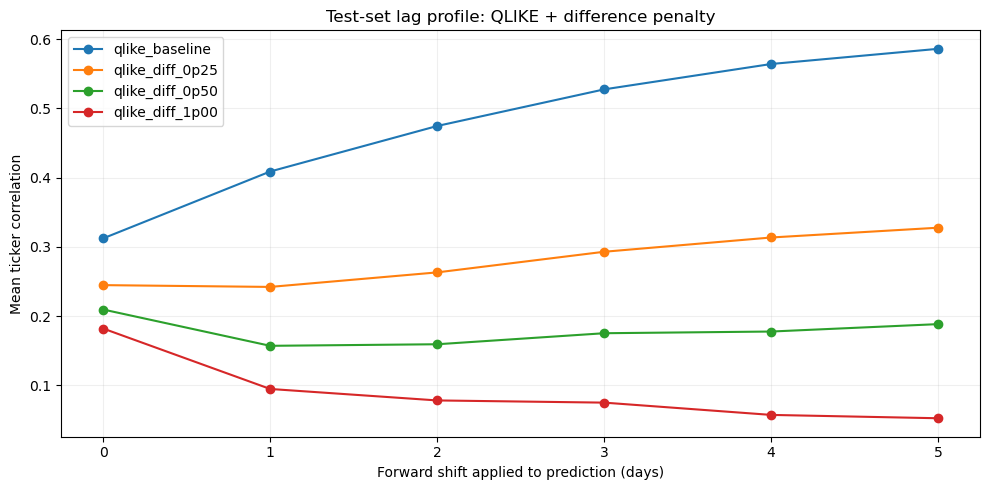

In [6]:
lag_plot_df = []
for name, lag_curve in test_lag_curve_map.items():
    curve = lag_curve.copy()
    curve['experiment'] = name
    lag_plot_df.append(curve)
lag_plot_df = pd.concat(lag_plot_df, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 5))
for name, group in lag_plot_df.groupby('experiment'):
    ax.plot(group['lag'], group['corr'], marker='o', label=name)
ax.set_title('Test-set lag profile: QLIKE + difference penalty')
ax.set_xlabel('Forward shift applied to prediction (days)')
ax.set_ylabel('Mean ticker correlation')
ax.legend(loc='best')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Five-stock comparison plot

This figure overlays the plain QLIKE baseline and the two strongest difference-penalty runs so we can visually check whether the turning points look less delayed.

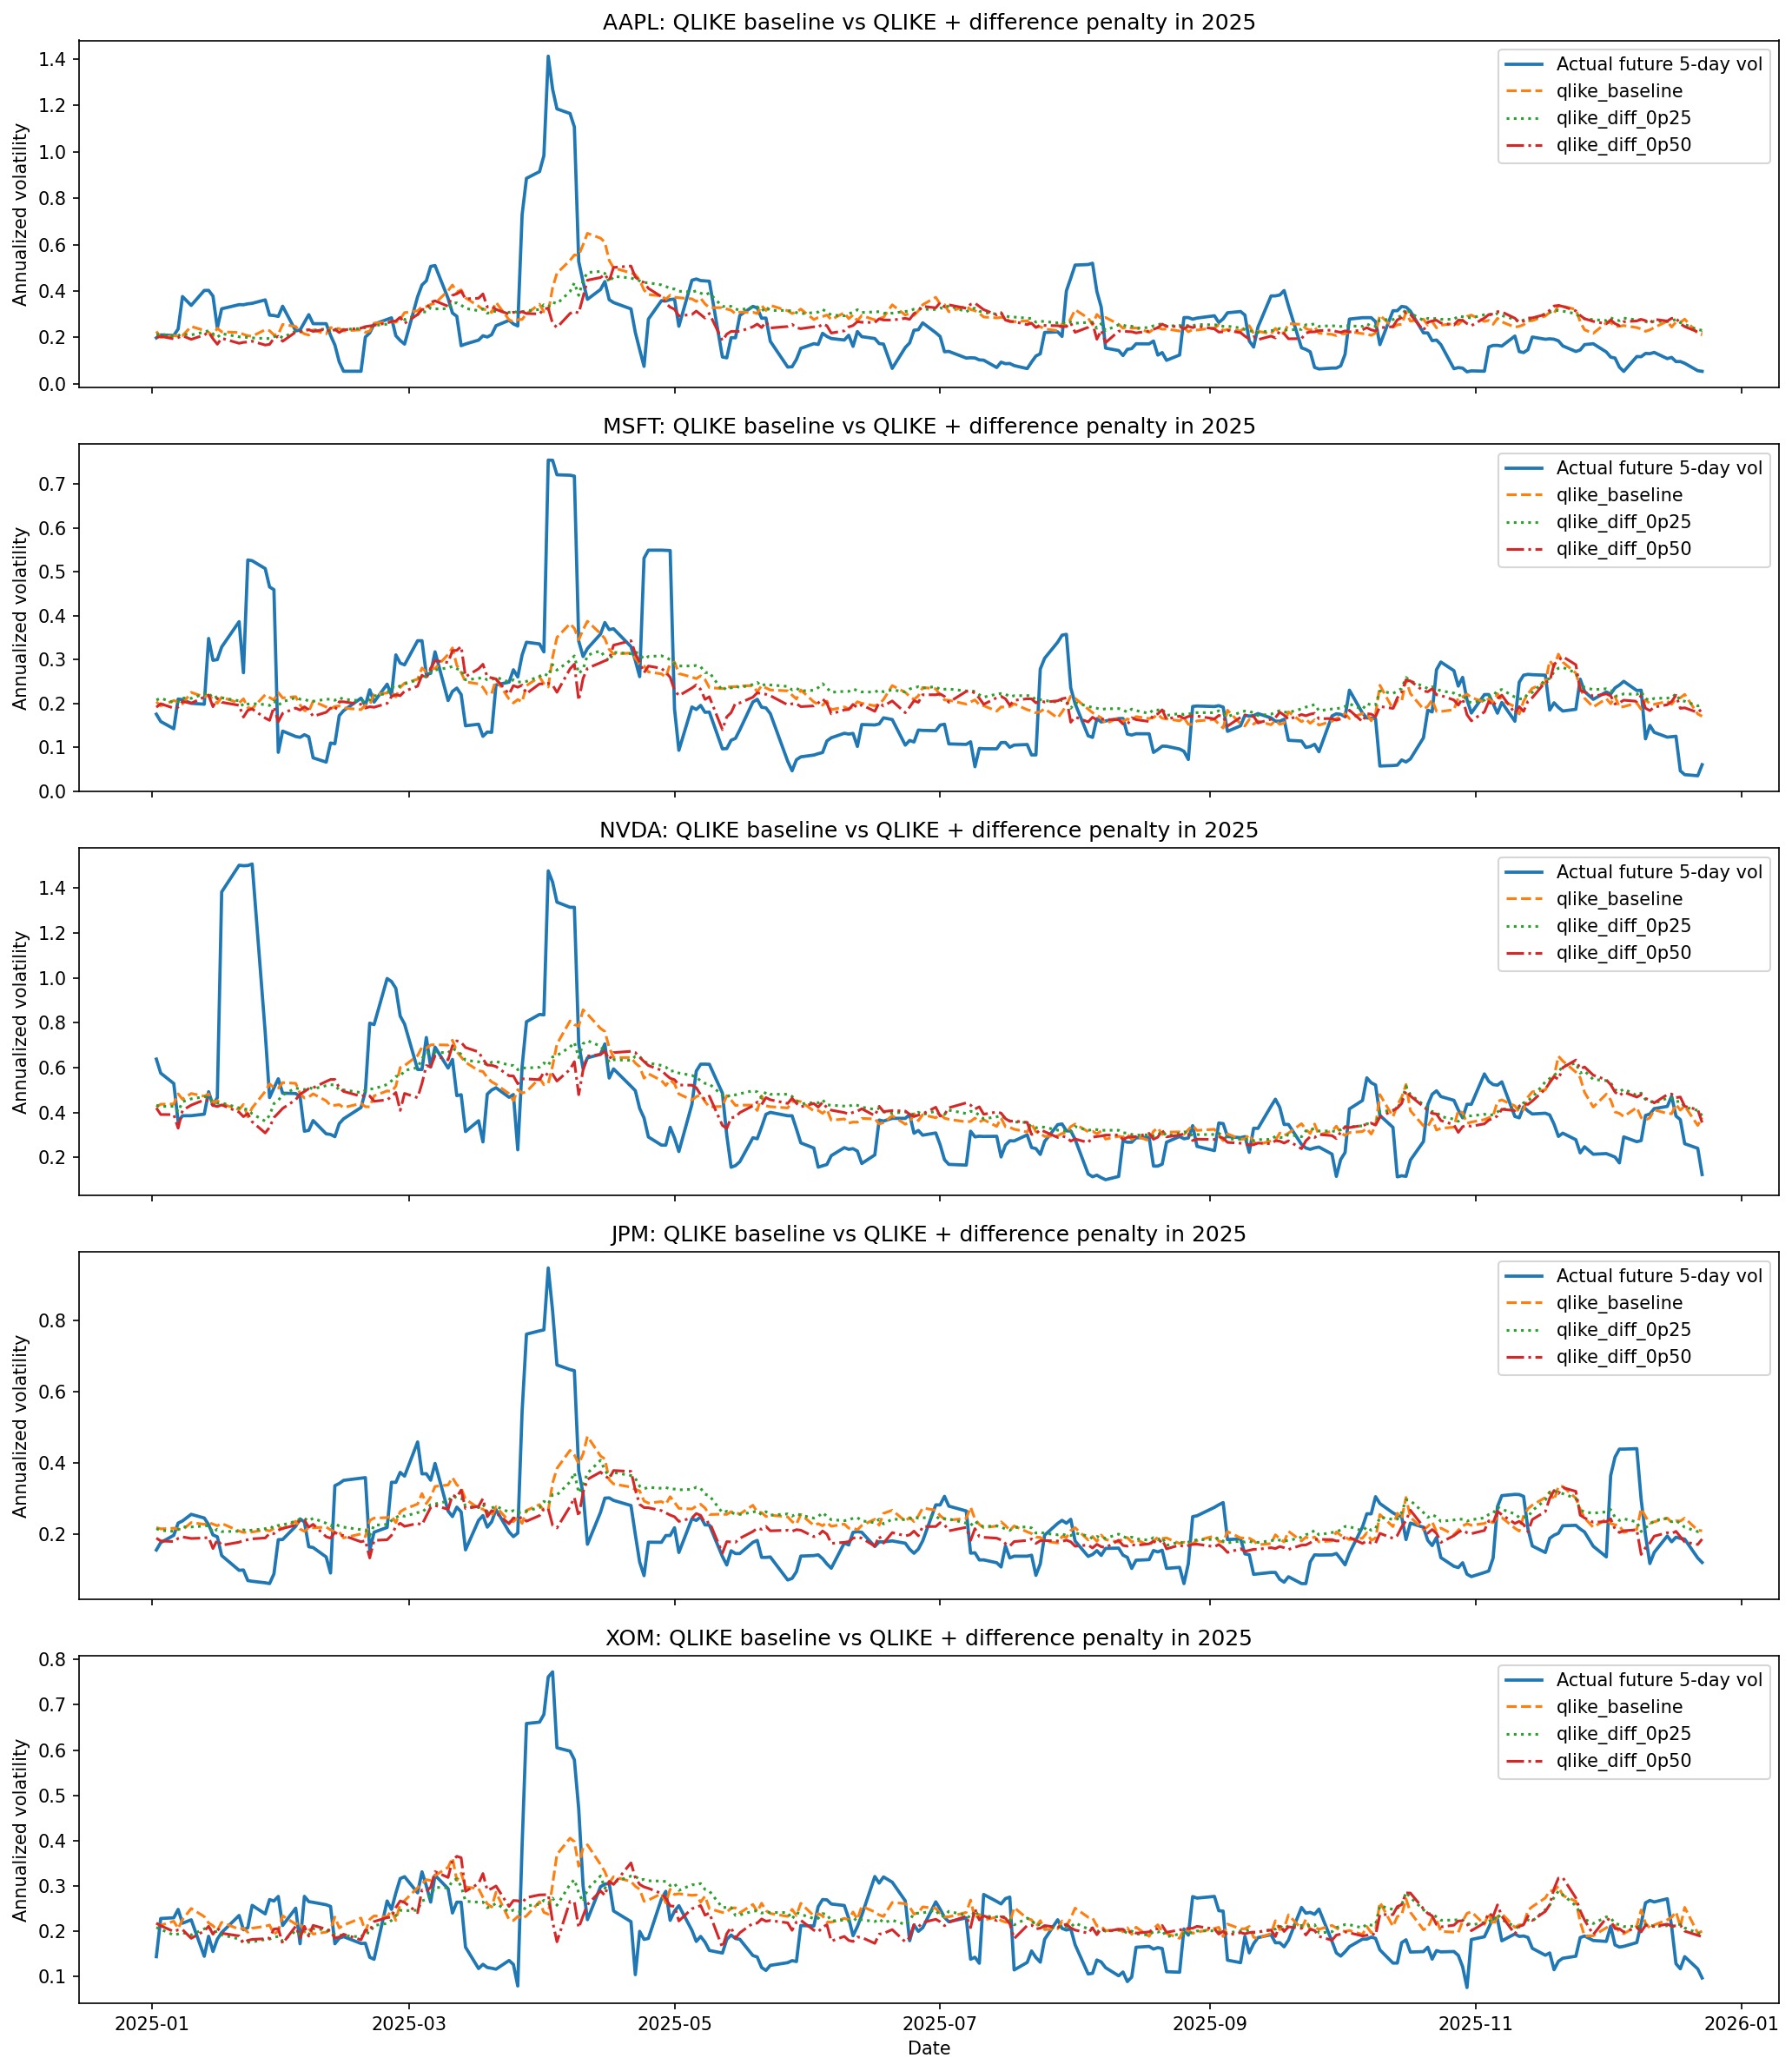

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_qlike_diff_penalty_5stocks.png')

In [7]:
baseline_name = 'qlike_baseline'
best_two_diff = experiment_summary_df[experiment_summary_df['experiment'] != baseline_name]['experiment'].head(2).tolist()
plot_experiments = [baseline_name] + best_two_diff

plot_df = test_prediction_map[plot_experiments[0]].rename(columns={'prediction': plot_experiments[0]})
for name in plot_experiments[1:]:
    plot_df = plot_df.merge(
        test_prediction_map[name][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': name}),
        on=['Date', 'Ticker'],
        how='left',
    )

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)
linestyles = ['--', ':', '-.']

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    for linestyle, name in zip(linestyles, plot_experiments):
        ax.plot(stock_plot_df['Date'], stock_plot_df[name], label=name, linestyle=linestyle, linewidth=1.5)
    ax.set_title(f'{ticker}: QLIKE baseline vs QLIKE + difference penalty in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'transformer_qlike_diff_penalty_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## How to read the result

The strongest outcome here would be a run that:

- lowers `lag_days`,
- raises `test_lag0_corr`,
- and keeps `RMSE / MAE / QLIKE` reasonably competitive.

If that happens, it means the difference penalty is helping the model move earlier rather than only smoothing the forecast more heavily.